In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
HI_dmax_clim = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmaxclim.nc')
HI_dmax_clim

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 478kB
Dimensions:            (month: 12, latitude: 82, longitude: 121)
Coordinates:
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude           (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude          (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
Data variables:
    HI_daily_max_clim  (month, latitude, longitude) float32 476kB ...

In [3]:
HI_dmax = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
HI_dmax

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [4]:
HIdmax_anom = HI_dmax['HI_daily_max'].groupby('time.month') - HI_dmax_clim
HIdmax_anom = HIdmax_anom['HI_daily_max_clim'].rename('HI_dmax_anom')
HIdmax_anom

<xarray.DataArray 'HI_dmax_anom' (time: 31471, latitude: 82, longitude: 121)> Size: 1GB
array([[[-2.2869186 , -2.5064545 , -2.804306  , ..., -1.4596558 ,
         -1.1788406 , -0.20955658],
        [-2.188652  , -2.4162521 , -2.7421417 , ..., -1.3799286 ,
         -0.13363647, -1.1835327 ],
        [-2.0727615 , -2.3111572 , -2.5543365 , ...,  0.954834  ,
         -1.2136536 , -1.3527527 ],
        ...,
        [ 2.1585312 ,  2.0330505 ,  1.9041443 , ...,  1.6762161 ,
          1.9024124 ,  2.327797  ],
        [ 2.139183  ,  2.0049057 ,  1.9147034 , ...,  0.5435562 ,
          1.1119003 ,  1.6317368 ],
        [ 1.8563843 ,  1.6500168 ,  1.4775162 , ...,  0.5783844 ,
          0.39038086,  0.9462967 ]],

       [[-2.1257172 , -2.1235352 ,  0.6615143 , ..., -0.22929382,
          0.22852325,  1.4149399 ],
        [-2.0496826 , -2.207985  , -2.452568  , ...,  0.27303314,
          1.7871399 ,  2.7879562 ],
        [-1.8559189 , -2.0732956 , -2.2474365 , ...,  2.6182098 ,
          2.682457  ,  1.6036453 ],
...
          4.3591766 ,  4.519905  ],
        [ 4.8866425 ,  5.2508163 ,  5.3712616 , ...,  4.169304  ,
          4.3558044 ,  4.4233627 ],
        [ 5.025032  ,  5.354477  ,  5.338089  , ...,  4.0356445 ,
          4.160881  ,  4.1572723 ]],

       [[-4.2801895 , -4.028702  , -0.9921417 , ...,  1.319046  ,
          1.048172  ,  0.86815643],
        [-4.2926407 , -3.994133  , -3.6334686 , ...,  2.0337982 ,
          1.5667038 ,  1.870369  ],
        [-4.445717  , -4.0115433 , -3.463234  , ...,  3.078537  ,
          2.1004257 ,  1.543251  ],
        ...,
        [ 2.3886719 ,  2.6019135 ,  2.7244186 , ...,  4.6937866 ,
          4.74131   ,  4.731148  ],
        [ 2.401802  ,  2.5360336 ,  2.6148376 , ...,  4.5005646 ,
          4.690483  ,  4.696556  ],
        [ 2.644722  ,  2.8029099 ,  2.8684921 , ...,  4.4440384 ,
          4.626404  ,  4.625992  ]]],
      shape=(31471, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-02-28
    month      (time) int64 252kB 1 1 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2 2
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

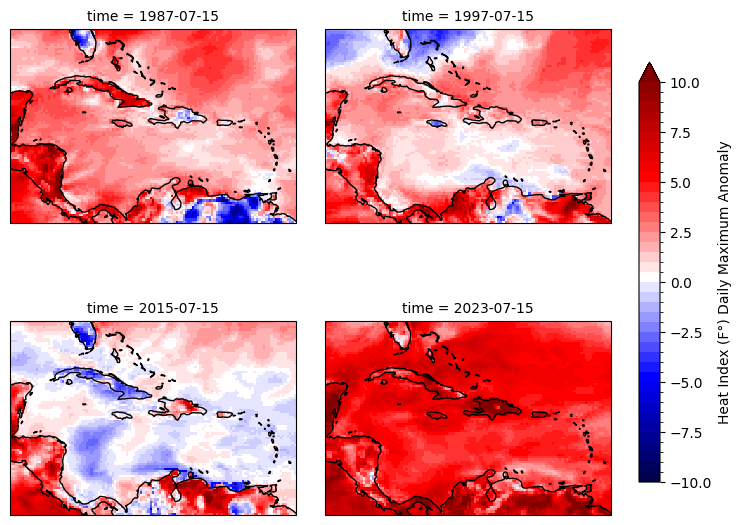

In [5]:
# strong ENSO in JJA
HIdmaxanom_plot = HIdmax_anom.sel(time=['1987-07-15', '1997-07-15', '2015-07-15', '2023-07-15']).plot(col='time',
                                                         col_wrap=2,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='seismic',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

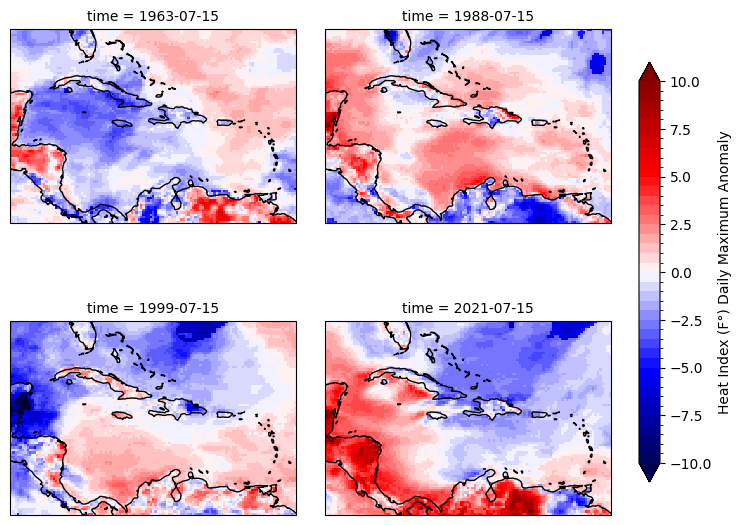

In [6]:
HIdmaxanom_plot = HIdmax_anom.sel(time=['1963-07-15', '1988-07-15', '1999-07-15', '2021-07-15']).plot(col='time',
                                                         col_wrap=2,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='seismic',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

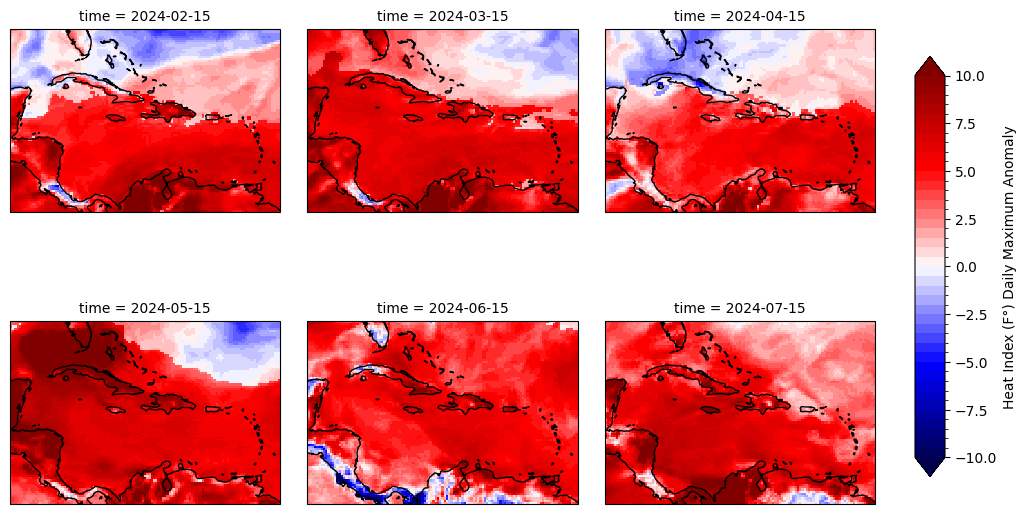

In [7]:
HIdmaxanom_plot = HIdmax_anom.sel(time=['2024-02-15', '2024-03-15', '2024-04-15', '2024-05-15', '2024-06-15', '2024-07-15']).plot(col='time',
                                                         col_wrap=3,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='seismic',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

In [38]:
HI_dmax_month_anom = HIdmax_anom.resample({'time': 'ME'}).mean()
HI_dmax_month_anom

<xarray.DataArray 'HI_dmax_anom' (time: 1034, latitude: 82, longitude: 121)> Size: 41MB
array([[[-1.7822756 , -1.8923955 , -1.8426452 , ..., -0.77452654,
         -0.96016496, -0.71722955],
        [-1.9621931 , -2.080394  , -2.3515854 , ..., -1.1060557 ,
         -0.64422065,  0.5235613 ],
        [-2.0496228 , -2.2238507 , -2.223337  , ..., -0.5199504 ,
          0.16507696,  0.39261332],
        ...,
        [-4.2814116 , -4.306459  , -4.3618703 , ..., -0.33233175,
         -0.32018992, -0.32271847],
        [-4.605498  , -4.6605144 , -4.716858  , ..., -0.4497213 ,
         -0.4757501 , -0.48040575],
        [-4.940091  , -4.989164  , -5.060758  , ..., -0.55093825,
         -0.5938337 , -0.60031396]],

       [[ 0.89815414,  0.645808  ,  0.46363226, ...,  0.280833  ,
          0.10370794,  0.30457807],
        [ 0.79514366,  0.7219275 ,  0.44596416, ..., -0.448817  ,
          0.15281914,  0.19386765],
        [ 0.6318317 ,  0.38366094,  0.2123742 , ...,  0.17254823,
          0.01594596,  0.2795447 ],
...
        [ 0.6799736 ,  0.71849465,  0.82170045, ...,  3.2686145 ,
          3.1942909 ,  3.145109  ],
        [ 0.76145625,  0.8005648 ,  0.86665726, ...,  3.3055816 ,
          3.235003  ,  3.1764283 ],
        [ 0.8505581 ,  0.8942832 ,  0.99349755, ...,  3.4219174 ,
          3.3643754 ,  3.30545   ]],

       [[ 0.330689  ,  0.62730736,  1.0715446 , ...,  3.8201606 ,
          3.9424303 ,  3.9442656 ],
        [-0.28449848, -0.02358763,  0.31976536, ...,  3.55624   ,
          3.7305188 ,  3.2869925 ],
        [-0.86082184, -0.5480905 , -0.21011107, ...,  3.8896825 ,
          3.4248393 ,  3.1741178 ],
        ...,
        [ 0.7021107 ,  0.82943493,  0.9479584 , ...,  1.8797008 ,
          1.8447944 ,  1.8988615 ],
        [ 0.8512821 ,  0.98780185,  1.0419627 , ...,  1.8048815 ,
          1.8575641 ,  1.9094378 ],
        [ 1.0242627 ,  1.1597035 ,  1.1840572 , ...,  1.7356834 ,
          1.8107283 ,  1.8627063 ]]], shape=(1034, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2026-02-28
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [39]:
HI_dmax_month_anom.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmax_month_anom.nc')